In [1]:
from pathlib import Path
from pystac_client import Client
import geopandas as gpd
from shapely.geometry import mapping
import planetary_computer

## setup connection

In [2]:
URL = "https://planetarycomputer.microsoft.com/api/stac/v1"
# custom headers
headers = []
client = Client.open(URL, headers=headers)
client

<Client id=microsoft-pc>

## Check all the data collection available in the stack url

In [212]:
for collection in client.get_collections():
    print(collection.assets)

{'thumbnail': <Asset href=https://ai4edatasetspublicassets.blob.core.windows.net/assets/pc_thumbnails/daymet-annual-pr.png>, 'zarr-abfs': <Asset href=abfs://daymet-zarr/annual/pr.zarr>, 'zarr-https': <Asset href=https://daymeteuwest.blob.core.windows.net/daymet-zarr/annual/pr.zarr>}
{'thumbnail': <Asset href=https://ai4edatasetspublicassets.blob.core.windows.net/assets/pc_thumbnails/daymet-daily-hi.png>, 'zarr-abfs': <Asset href=abfs://daymet-zarr/daily/hi.zarr>, 'zarr-https': <Asset href=https://daymeteuwest.blob.core.windows.net/daymet-zarr/daily/hi.zarr>}
{'thumbnail': <Asset href=https://ai4edatasetspublicassets.blob.core.windows.net/assets/pc_thumbnails/threedep.png>, 'geoparquet-items': <Asset href=abfs://items/3dep-seamless.parquet>}
{'thumbnail': <Asset href=https://ai4edatasetspublicassets.blob.core.windows.net/assets/pc_thumbnails/dsm-thumbnail.png>, 'geoparquet-items': <Asset href=abfs://items/3dep-lidar-dsm.parquet>}
{'guide': <Asset href=https://www.fia.fs.fed.us/library/d

## or search collection by name

In [213]:
collection_search = client.collection_search(q='sentinel 2')
for result in collection_search.collections():
    print(result.id)

d:\Personal Projects\STACK_API\pySTACK_Client\.venv\Lib\site-packages\pystac_client\collection_search.py:306: UserWarning: Server does not conform to COLLECTION_SEARCH. Filtering will be performed client-side where only bbox, datetime, and q arguments are supported
  warnings.warn(


io-lulc-annual-v02
sentinel-2-l2a
io-lulc
io-lulc-9-class
sentinel-5p-l2-netcdf
sentinel-3-olci-wfr-l2-netcdf
sentinel-3-synergy-aod-l2-netcdf
sentinel-3-synergy-v10-l2-netcdf
sentinel-3-olci-lfr-l2-netcdf
sentinel-3-sral-lan-l2-netcdf
sentinel-3-slstr-lst-l2-netcdf
sentinel-3-slstr-wst-l2-netcdf
sentinel-3-sral-wat-l2-netcdf
hls2-s30
sentinel-3-slstr-frp-l2-netcdf
sentinel-3-synergy-syn-l2-netcdf
sentinel-3-synergy-vgp-l2-netcdf
sentinel-3-synergy-vg1-l2-netcdf
esa-worldcover
hls2-l30


## Inspect about the metadeta of the collection

In [164]:
collection = client.get_collection('sentinel-1-grd')
collection

<CollectionClient id=sentinel-1-grd>

## To filter out desired data we have to perform filters. The scripts below provides list of queryables 

In [165]:
queryables = collection.get_queryables()
list(queryables["properties"].keys())

['id',
 'datetime',
 'geometry',
 'platform',
 's1:shape',
 'end_datetime',
 'constellation',
 's1:resolution',
 's1:datatake_id',
 'start_datetime',
 's1:orbit_source',
 's1:slice_number',
 's1:total_slices',
 'sar:looks_range',
 'sat:orbit_state',
 'sar:product_type',
 'sar:looks_azimuth',
 'sar:polarizations',
 'sar:frequency_band',
 'sat:absolute_orbit',
 'sat:relative_orbit',
 's1:processing_level',
 'sar:instrument_mode',
 'sar:center_frequency',
 'sar:resolution_range',
 's1:product_timeliness',
 'sar:resolution_azimuth',
 'sar:pixel_spacing_range',
 'sar:observation_direction',
 'sar:pixel_spacing_azimuth',
 'sar:looks_equivalent_number',
 's1:instrument_configuration_ID',
 'sat:platform_international_designator']

In [59]:
# AOI
MAIN_DIR = Path.cwd().parent   # parent of current working directory
gpkg_path = MAIN_DIR / "input_data" / "vectors" / "146247.gpkg"
if gpkg_path.exists():
    gdf = gpd.read_file(gpkg_path)
else:
    raise FileExistsError ("Please provide a valid file path")

## for stack search gdf needs in EPSG: 4326
if gdf.crs != "EPSG:4326":
    gdf = gdf.to_crs(epsg=4226)
gdf.geometry = gdf.buffer(0.0045)
AOI_id = 0
AOI = gdf.geometry.iloc[AOI_id]
geometry = mapping(AOI)

## Search the items in the collections
# https://pystac-client.readthedocs.io/en/latest/tutorials/cql2-filter.html
# https://developmentseed.org/cql2-rs/latest/playground/

C:\Users\HP\AppData\Local\Temp\ipykernel_3564\1708768417.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf.geometry = gdf.buffer(0.0045)


## Item Search
When the Catalog is a STAC API, we have the ability to search for items based on spatio-temporal properties.

Get the items (items doesn't contain data itself, its stores metadeta and storage url)

### this is CQL2 Json
filter = {"op": "<=", "args": [{"property": "eo:cloud_cover"}, 10]}
### this is CQL2 Text
filter = "eo:cloud_cover<=60 and eo:cloud_cover>=40"
### to construct CQL2 text to json visit this website
https://developmentseed.org/cql2-rs/latest/playground/

In [4]:

search_instance = client.search(collections=['sentinel-2-l2a'],
    datetime='2026-01-01/2026-02-01',
    intersects=geometry,
    filter='eo:cloud_cover<=50'
    )
# get the items from instance
items = list(search_instance.items())

# get the signed items so that we can fetch data from cloud without errors
signed_items = [planetary_computer.sign(item) for item in items]
signed_items

[<Item id=S2C_MSIL2A_20260130T052051_R062_T43PFR_20260130T100710>,
 <Item id=S2B_MSIL2A_20260125T052009_R062_T43PFR_20260125T090625>,
 <Item id=S2C_MSIL2A_20260120T052131_R062_T43PFR_20260120T083615>,
 <Item id=S2B_MSIL2A_20260115T052049_R062_T43PFR_20260115T090435>,
 <Item id=S2C_MSIL2A_20260110T052211_R062_T43PFR_20260110T082921>,
 <Item id=S2B_MSIL2A_20260105T052119_R062_T43PFR_20260105T074657>]

## Visualize the tif boundary and aoi

In [168]:
from copy import deepcopy

import pandas as pd
from shapely.geometry import shape


# convert a list of STAC Items into a GeoDataFrame
def items_to_geodataframe(items):
    _items = []
    for i in items:
        i = i.to_dict()
        _i = deepcopy(i)
        _i["geometry"] = shape(_i["geometry"])
        _items.append(_i)
    gdf = gpd.GeoDataFrame(pd.json_normalize(_items))
    for field in ["properties.datetime", "properties.created", "properties.updated"]:
        if field in gdf:
            gdf[field] = pd.to_datetime(gdf[field])
    gdf.set_index("properties.datetime", inplace=True)
    return gdf

In [169]:
# convert found items to a GeoDataFrame
items_gdf = items_to_geodataframe(signed_items)
items_gdf.head()

,type,stac_version,stac_extensions,id,geometry,bbox,links,collection,properties.platform,properties.instruments,...,assets.datastrip-metadata.roles,assets.tilejson.href,assets.tilejson.type,assets.tilejson.title,assets.tilejson.roles,assets.rendered_preview.href,assets.rendered_preview.type,assets.rendered_preview.title,assets.rendered_preview.rel,assets.rendered_preview.roles
properties.datetime,,,,,,,,,,,,,,,,,,,,,
2026-01-30 05:20:51.025000+00:00,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.1.0/s...,S2C_MSIL2A_20260130T052051_R062_T43PFR_2026013...,"POLYGON ((75.92789 14.471, 76.9464 14.46478, 7...","[75.9239229, 13.4725398, 76.9464047, 14.4710005]","[{'rel': 'collection', 'href': 'https://planet...",sentinel-2-l2a,Sentinel-2C,[msi],...,[metadata],https://planetarycomputer.microsoft.com/api/da...,application/json,TileJSON with default rendering,[tiles],https://planetarycomputer.microsoft.com/api/da...,image/png,Rendered preview,preview,[overview]
2026-01-25 05:20:09.024000+00:00,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.1.0/s...,S2B_MSIL2A_20260125T052009_R062_T43PFR_2026012...,"POLYGON ((75.92789 14.471, 76.9464 14.46478, 7...","[75.9239229, 13.4725398, 76.9464047, 14.4710005]","[{'rel': 'collection', 'href': 'https://planet...",sentinel-2-l2a,Sentinel-2B,[msi],...,[metadata],https://planetarycomputer.microsoft.com/api/da...,application/json,TileJSON with default rendering,[tiles],https://planetarycomputer.microsoft.com/api/da...,image/png,Rendered preview,preview,[overview]
2026-01-20 05:21:31.025000+00:00,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.1.0/s...,S2C_MSIL2A_20260120T052131_R062_T43PFR_2026012...,"POLYGON ((75.92789 14.471, 76.9464 14.46478, 7...","[75.9239229, 13.4725398, 76.9464047, 14.4710005]","[{'rel': 'collection', 'href': 'https://planet...",sentinel-2-l2a,Sentinel-2C,[msi],...,[metadata],https://planetarycomputer.microsoft.com/api/da...,application/json,TileJSON with default rendering,[tiles],https://planetarycomputer.microsoft.com/api/da...,image/png,Rendered preview,preview,[overview]
2026-01-15 05:20:49.024000+00:00,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.1.0/s...,S2B_MSIL2A_20260115T052049_R062_T43PFR_2026011...,"POLYGON ((75.92789 14.471, 76.9464 14.46478, 7...","[75.9239229, 13.4725398, 76.9464047, 14.4710005]","[{'rel': 'collection', 'href': 'https://planet...",sentinel-2-l2a,Sentinel-2B,[msi],...,[metadata],https://planetarycomputer.microsoft.com/api/da...,application/json,TileJSON with default rendering,[tiles],https://planetarycomputer.microsoft.com/api/da...,image/png,Rendered preview,preview,[overview]
2026-01-10 05:22:11.025000+00:00,Feature,1.1.0,[https://stac-extensions.github.io/eo/v1.1.0/s...,S2C_MSIL2A_20260110T052211_R062_T43PFR_2026011...,"POLYGON ((75.92789 14.471, 76.9464 14.46478, 7...","[75.9239229, 13.4725398, 76.9464047, 14.4710005]","[{'rel': 'collection', 'href': 'https://planet...",sentinel-2-l2a,Sentinel-2C,[msi],...,[metadata],https://planetarycomputer.microsoft.com/api/da...,application/json,TileJSON with default rendering,[tiles],https://planetarycomputer.microsoft.com/api/da...,image/png,Rendered preview,preview,[overview]


In [170]:
list(items_gdf.columns)

['type',
 'stac_version',
 'stac_extensions',
 'id',
 'geometry',
 'bbox',
 'links',
 'collection',
 'properties.platform',
 'properties.instruments',
 'properties.s2:mgrs_tile',
 'properties.constellation',
 'properties.s2:granule_id',
 'properties.eo:cloud_cover',
 'properties.s2:datatake_id',
 'properties.s2:product_uri',
 'properties.s2:datastrip_id',
 'properties.s2:product_type',
 'properties.sat:orbit_state',
 'properties.s2:datatake_type',
 'properties.s2:generation_time',
 'properties.sat:relative_orbit',
 'properties.s2:water_percentage',
 'properties.s2:mean_solar_zenith',
 'properties.s2:mean_solar_azimuth',
 'properties.s2:processing_baseline',
 'properties.s2:snow_ice_percentage',
 'properties.s2:vegetation_percentage',
 'properties.s2:thin_cirrus_percentage',
 'properties.s2:cloud_shadow_percentage',
 'properties.s2:nodata_pixel_percentage',
 'properties.s2:unclassified_percentage',
 'properties.s2:not_vegetated_percentage',
 'properties.s2:degraded_msi_data_percentage',

<Axes: xlabel='properties.datetime', ylabel='Cloud Cover percentage'>

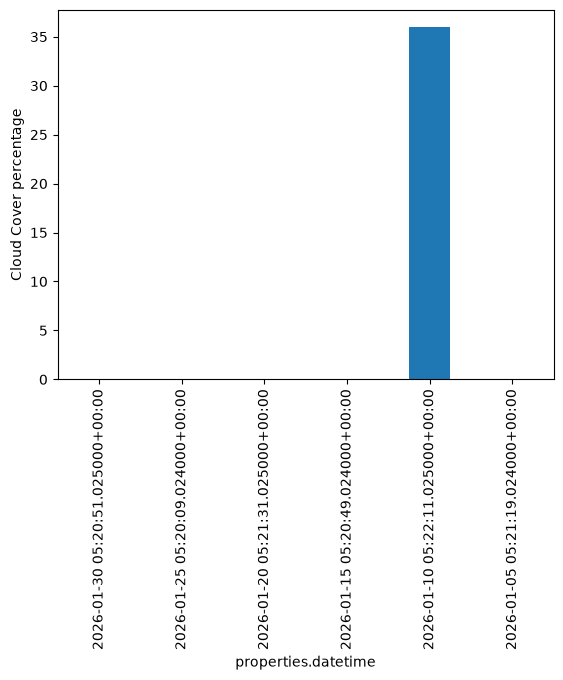

In [171]:
items_gdf['properties.eo:cloud_cover'].plot(ylabel='Cloud Cover percentage', kind='bar')

### To know more about available tiles visit
https://holoviews.org/reference/elements/bokeh/Tiles.html

and read hvplot documentation for further improvement

In [172]:
import hvplot.pandas  # noqa: F401


# plot polygons on a map with background tiles.
def plot_polygons(data, line_width=1, *args, **kwargs):
    return data.hvplot.polygons(
        *args,
        geo=True,
        projection="GOOGLE_MERCATOR",
        xaxis=None,
        yaxis=None,
        frame_width=600,
        frame_height=600,
        fill_alpha=0,
        line_width=line_width,
        **kwargs,
    )

In [173]:
plot_polygons(items_gdf, tiles="EsriImagery") * plot_polygons(gdf, line_color="red", line_width=10)

:Overlay
   .WMTS.I      :WMTS   [Longitude,Latitude]
   .Polygons.I  :Polygons   [Longitude,Latitude]
   .Polygons.II :Polygons   [Longitude,Latitude]

## Preview the rgb image

In [174]:
import matplotlib.pyplot as plt
import requests
from PIL import Image as PILImage
from io import BytesIO
def preview_rgb_tiles(item):
    url = item.assets['rendered_preview'].href
    date = item.properties['datetime']
    cloud_cover = item.properties['eo:cloud_cover']
    response = requests.get(url)
    img = PILImage.open(BytesIO(response.content))

    plt.imshow(img)
    plt.title(f"{date} \n Cloud Cover Percentage {round(cloud_cover, 4)}")
    plt.axis("off")
    plt.show()
    # return img



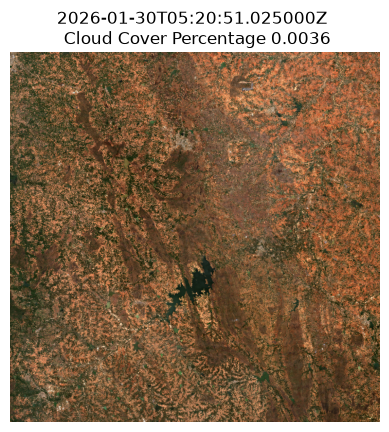

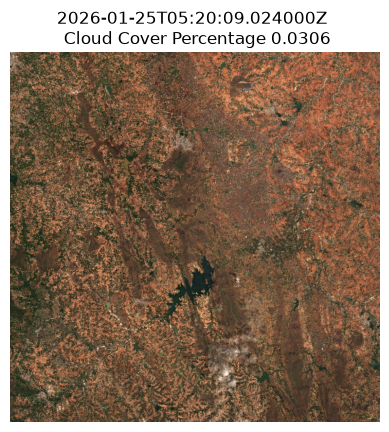

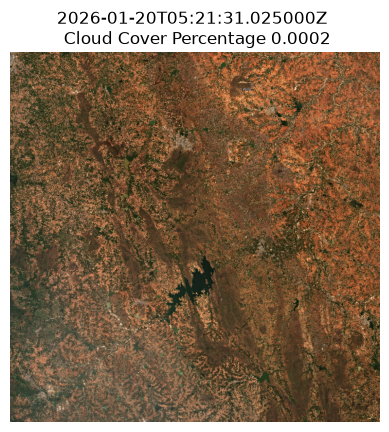

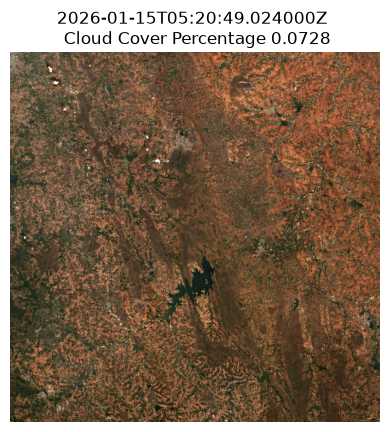

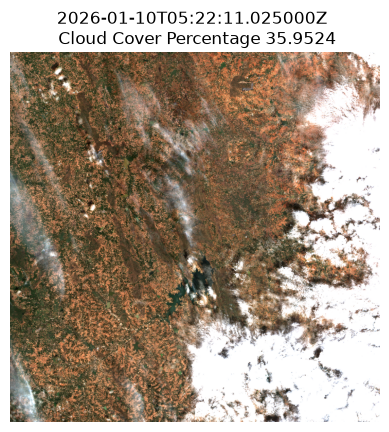

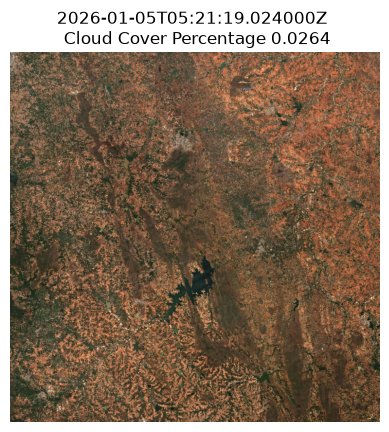

In [175]:
for item in signed_items:
    preview_rgb_tiles(item)

In [5]:
item = signed_items[0]
def get_bands_info(item):

    print(f'Band', 10*"-", 'Title')
    for band in list(item.assets.keys()):
        print(f"{band}, {item.assets[band].title}")
def get_band_info(item, band):
    print(item.assets[band].title)


In [6]:
get_band_info(item, 'B05')

Band 5 - Vegetation red edge 1 - 20m


In [7]:
get_bands_info(item)

Band ---------- Title
AOT, Aerosol optical thickness (AOT)
B01, Band 1 - Coastal aerosol - 60m
B02, Band 2 - Blue - 10m
B03, Band 3 - Green - 10m
B04, Band 4 - Red - 10m
B05, Band 5 - Vegetation red edge 1 - 20m
B06, Band 6 - Vegetation red edge 2 - 20m
B07, Band 7 - Vegetation red edge 3 - 20m
B08, Band 8 - NIR - 10m
B09, Band 9 - Water vapor - 60m
B11, Band 11 - SWIR (1.6) - 20m
B12, Band 12 - SWIR (2.2) - 20m
B8A, Band 8A - Vegetation red edge 4 - 20m
SCL, Scene classfication map (SCL)
WVP, Water vapour (WVP)
visual, True color image
safe-manifest, SAFE manifest
granule-metadata, Granule metadata
inspire-metadata, INSPIRE metadata
product-metadata, Product metadata
datastrip-metadata, Datastrip metadata
tilejson, TileJSON with default rendering
rendered_preview, Rendered preview


In [180]:
item

<Item id=S2C_MSIL2A_20260130T052051_R062_T43PFR_20260130T100710>

### As we got STACK items. Now we have load data specified path in Items. The COG data can be store in any cloud platform such as AWS S3 or Azure blob storage

In [8]:
url_1 = item.assets['B04'].href
import rasterio
with rasterio.open(url_1) as test_src:
    print(test_src.crs)
    print(test_src.profile)
    print(test_src.res)


EPSG:32643
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': 0.0, 'width': 10980, 'height': 10980, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 43N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32643"]]'), 'transform': Affine(10.0, 0.0, 600000.0,
       0.0, -10.0, 1600020.0), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'deflate', 'interleave': 'band'}
(10.0, 10.0)


In [9]:
from odc.stac import load

In [11]:
import numpy as np

In [12]:
def get_utm(lat, lon):
    utm_zone = int((lon + 180) // 6) + 1

    if lat >= 0:
        epsg = 32600 + utm_zone
    else:
        epsg = 32700 + utm_zone

    utm_crs = f"EPSG:{epsg}"
    return utm_crs

In [13]:
lat= gdf.geometry[0].centroid.y
lon= gdf.geometry[0].centroid.x

In [14]:
utm_crs = get_utm(lat=lat, lon=lon)


In [60]:
ds = load(signed_items, bands=['B02','B03','B04', 'B08', 'SCL'], groupby='solar_day', resolution=10, crs=utm_crs, resampling={
    "B04": "bilinear",
    "B08": "bilinear",
    "SCL": "nearest"
},
geopolygon=geometry)

In [61]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:      (y: 114, x: 112, time: 6)
Coordinates:
  * y            (y) float64 912B 1.514e+06 1.514e+06 ... 1.513e+06 1.513e+06
  * x            (x) float64 896B 6.926e+05 6.926e+05 ... 6.937e+05 6.937e+05
  * time         (time) datetime64[us] 48B 2026-01-05T05:21:19.024000 ... 202...
    spatial_ref  int32 4B 32643
Data variables:
    B02          (time, y, x) float32 306kB 1.378e+03 1.347e+03 ... 1.308e+03
    B03          (time, y, x) float32 306kB 1.574e+03 1.538e+03 ... 1.498e+03
    B04          (time, y, x) float32 306kB 1.718e+03 1.655e+03 ... 1.746e+03
    B08          (time, y, x) float32 306kB 2.914e+03 2.862e+03 ... 2.598e+03
    SCL          (time, y, x) float32 306kB 5.0 5.0 5.0 5.0 ... 5.0 5.0 5.0 5.0

### For better data handeling with xarray, follow this tuitorial
https://tutorial.xarray.dev/overview/xarray-in-45-min

## ODC geobox
This will help you understand:

CRS

resolution

affine transform

width

height

spatial extent

output grid

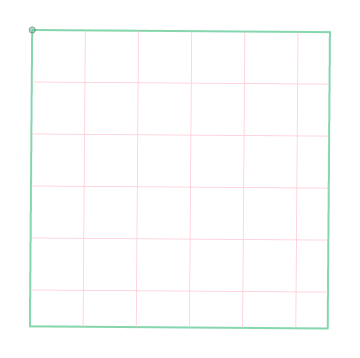

In [62]:
ds.odc.geobox

In [63]:
# understand the dimention
print(ds.dims)
print(ds.coords)

FrozenMappingWarningOnValuesAccess({'y': 114, 'x': 112, 'time': 6})
Coordinates:
  * y            (y) float64 912B 1.514e+06 1.514e+06 ... 1.513e+06 1.513e+06
  * x            (x) float64 896B 6.926e+05 6.926e+05 ... 6.937e+05 6.937e+05
  * time         (time) datetime64[us] 48B 2026-01-05T05:21:19.024000 ... 202...
    spatial_ref  int32 4B 32643


In [19]:
print(ds.time)
print(ds.x)
print(ds.y)

<xarray.DataArray 'time' (time: 6)> Size: 48B
array(['2026-01-05T05:21:19.024000', '2026-01-10T05:22:11.025000',
       '2026-01-15T05:20:49.024000', '2026-01-20T05:21:31.025000',
       '2026-01-25T05:20:09.024000', '2026-01-30T05:20:51.025000'],
      dtype='datetime64[us]')
Coordinates:
  * time         (time) datetime64[us] 48B 2026-01-05T05:21:19.024000 ... 202...
    spatial_ref  int32 4B 32643
<xarray.DataArray 'x' (x: 14)> Size: 112B
array([693055., 693065., 693075., 693085., 693095., 693105., 693115., 693125.,
       693135., 693145., 693155., 693165., 693175., 693185.])
Coordinates:
  * x            (x) float64 112B 6.931e+05 6.931e+05 ... 6.932e+05 6.932e+05
    spatial_ref  int32 4B 32643
Attributes:
    units:       metre
    resolution:  10.0
    crs:         EPSG:32643
<xarray.DataArray 'y' (y: 14)> Size: 112B
array([1513345., 1513335., 1513325., 1513315., 1513305., 1513295., 1513285.,
       1513275., 1513265., 1513255., 1513245., 1513235., 1513225., 1513215.])
Coordina

### date selection

In [20]:
print(ds.time.values)

['2026-01-05T05:21:19.024000' '2026-01-10T05:22:11.025000'
 '2026-01-15T05:20:49.024000' '2026-01-20T05:21:31.025000'
 '2026-01-25T05:20:09.024000' '2026-01-30T05:20:51.025000']


In [21]:
image = ds.sel(time='2026-01-05')
image

<xarray.Dataset> Size: 4kB
Dimensions:      (y: 14, x: 14, time: 1)
Coordinates:
  * y            (y) float64 112B 1.513e+06 1.513e+06 ... 1.513e+06 1.513e+06
  * x            (x) float64 112B 6.931e+05 6.931e+05 ... 6.932e+05 6.932e+05
  * time         (time) datetime64[us] 8B 2026-01-05T05:21:19.024000
    spatial_ref  int32 4B 32643
Data variables:
    B02          (time, y, x) float32 784B 1.534e+03 1.629e+03 ... 2.13e+03
    B03          (time, y, x) float32 784B 1.741e+03 1.797e+03 ... 2.114e+03
    B04          (time, y, x) float32 784B 1.933e+03 2.13e+03 ... 2.262e+03
    B08          (time, y, x) float32 784B 3.03e+03 3.206e+03 ... 2.824e+03
    SCL          (time, y, x) float32 784B 5.0 5.0 5.0 5.0 ... 5.0 5.0 5.0 5.0

In [22]:
image.SCL.values[0]

array([[5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.],
       [5., 5., 5., 5., 5., 5., 5., 4., 4., 4., 4., 5., 5., 5.],
       [5., 5., 5., 5., 5., 5., 5., 4., 4., 4., 4., 5., 5., 5.],
       [5., 5., 5., 5., 5., 4., 4., 4., 4., 4., 4., 5., 5., 5.],
       [5., 5., 5., 5., 5., 4., 4., 4., 4., 4., 4., 5., 5., 5.],
       [5., 5., 5., 5., 5., 4., 4., 4., 4., 5., 5., 5., 5., 5.],
       [5., 5., 5., 5., 5., 4., 4., 4., 4., 5., 5., 5., 5., 5.],
       [5., 5., 5., 4., 4., 4., 4., 4., 4., 5., 5., 5., 5., 5.],
       [5., 5., 5., 4., 4., 4., 4., 4., 4., 5., 5., 5., 5., 5.],
       [5., 4., 4., 4., 4., 4., 4., 5., 5., 5., 5., 5., 5., 5.],
       [5., 4., 4., 4., 4., 4., 4., 5., 5., 5., 5., 5., 5., 5.],
       [5., 5., 5., 4., 4., 5., 5., 5., 5., 5., 5., 5., 5., 5.],
       [5., 5., 5., 4., 4., 5., 5., 5., 5., 5., 5., 5., 5., 5.],
       [5., 7., 7., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.]],
      dtype=float32)

## Cloud masking

In [64]:
valid = ~ds.SCL.isin([3, 8, 9, 10, 11])
red = ds.B04.where(valid)
nir = ds.B08.where(valid)

In [65]:
ndvi = (nir-red)/(nir+red)
ndvi

<xarray.DataArray (time: 6, y: 114, x: 112)> Size: 306kB
array([[[0.2582038 , 0.26721275, 0.26167402, ..., 0.21197793,
         0.19750682, 0.17218544],
        [0.30406505, 0.2918543 , 0.26600167, ..., 0.21409002,
         0.20670392, 0.16816817],
        [0.22896855, 0.20728597, 0.17487141, ..., 0.22220035,
         0.24733876, 0.20414507],
        ...,
        [0.3099662 , 0.27592632, 0.30858678, ..., 0.12816326,
         0.13542977, 0.1574904 ],
        [0.2545099 , 0.25992543, 0.3187473 , ..., 0.14884607,
         0.16514954, 0.19317926],
        [0.23334765, 0.26686218, 0.3036566 , ..., 0.15005624,
         0.16854969, 0.18066636]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [0.25021872, 0.23227176, 0.25381288, ..., 0.10825384,
         0.12341505, 0.14347172],
        [0.21097615, 0.21968062, 0.2807175 , ..., 0.12510711,
         0.16038562, 0.18256131],
        [0.21493703, 0.23050848, 0.25282362, ..., 0.12700596,
         0.1482001 , 0.17496444]],

       [[0.22663252, 0.22994652, 0.2059279 , ..., 0.18946145,
         0.16394717, 0.14877868],
        [0.26302627, 0.24346744, 0.2058142 , ..., 0.17985612,
         0.18697897, 0.15333822],
        [0.18090264, 0.16199848, 0.15293215, ..., 0.1867065 ,
         0.1995173 , 0.17898063],
        ...,
        [0.29209015, 0.26262838, 0.27607915, ..., 0.12205045,
         0.13429157, 0.16300675],
        [0.24218051, 0.24967434, 0.2889185 , ..., 0.13682432,
         0.17626826, 0.22139412],
        [0.24690016, 0.2663066 , 0.2892697 , ..., 0.14545454,
         0.18081181, 0.1961326 ]]], shape=(6, 114, 112), dtype=float32)
Coordinates:
  * time         (time) datetime64[us] 48B 2026-01-05T05:21:19.024000 ... 202...
  * y            (y) float64 912B 1.514e+06 1.514e+06 ... 1.513e+06 1.513e+06
  * x            (x) float64 896B 6.926e+05 6.926e+05 ... 6.937e+05 6.937e+05
    spatial_ref  int32 4B 32643

In [66]:
ds['ndvi'] = ndvi

In [67]:
ds

<xarray.Dataset> Size: 2MB
Dimensions:      (y: 114, x: 112, time: 6)
Coordinates:
  * y            (y) float64 912B 1.514e+06 1.514e+06 ... 1.513e+06 1.513e+06
  * x            (x) float64 896B 6.926e+05 6.926e+05 ... 6.937e+05 6.937e+05
  * time         (time) datetime64[us] 48B 2026-01-05T05:21:19.024000 ... 202...
    spatial_ref  int32 4B 32643
Data variables:
    B02          (time, y, x) float32 306kB 1.378e+03 1.347e+03 ... 1.308e+03
    B03          (time, y, x) float32 306kB 1.574e+03 1.538e+03 ... 1.498e+03
    B04          (time, y, x) float32 306kB 1.718e+03 1.655e+03 ... 1.746e+03
    B08          (time, y, x) float32 306kB 2.914e+03 2.862e+03 ... 2.598e+03
    SCL          (time, y, x) float32 306kB 5.0 5.0 5.0 5.0 ... 5.0 5.0 5.0 5.0
    ndvi         (time, y, x) float32 306kB 0.2582 0.2672 ... 0.1808 0.1961

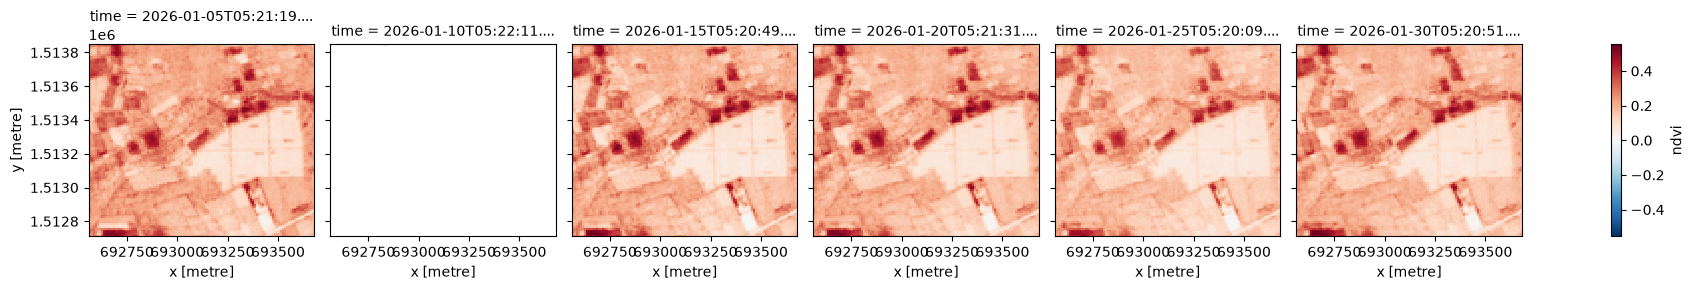

In [68]:
ds.ndvi.plot(col='time')

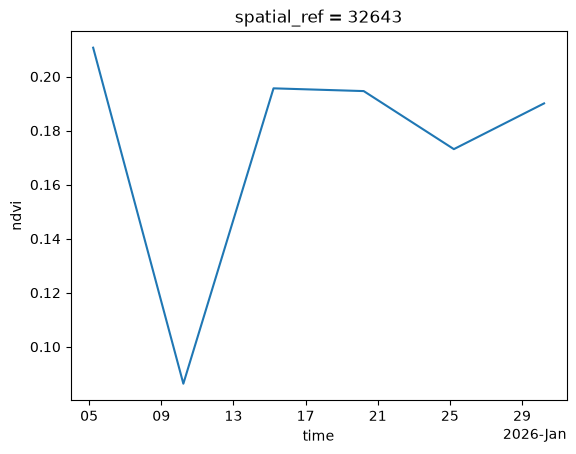

In [69]:
farm_ndvi_mean = ds.ndvi.mean(dim=["x", "y"])
farm_ndvi_mean.plot()

(array([  57., 1573., 2284., 4323., 2447., 1064.,  483.,  277.,  196.,
          64.]),
 array([-0.01438466,  0.04199452,  0.0983737 ,  0.15475288,  0.21113205,
         0.26751122,  0.32389042,  0.38026959,  0.43664876,  0.49302796,
         0.54940712]),
 <BarContainer object of 10 artists>)

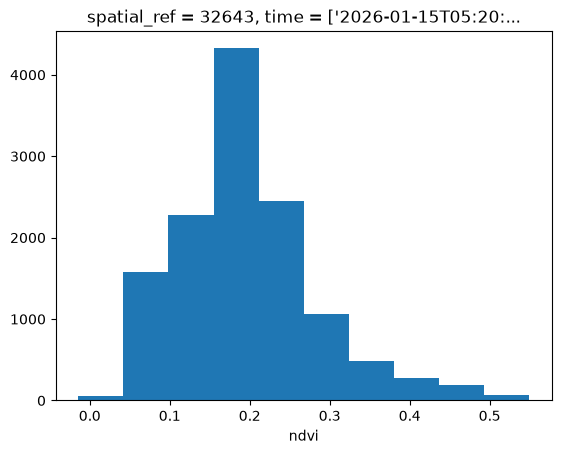

In [70]:
ds.ndvi.sel(time="2026-01-15").plot.hist()

In [276]:
b4 = image.B04
b4.odc.write_cog('../output/b4.tif')

WindowsPath('../output/b4.tif')

In [278]:
ds.coords

Coordinates:
  * y            (y) float64 112B 1.513e+06 1.513e+06 ... 1.513e+06 1.513e+06
  * x            (x) float64 112B 6.931e+05 6.931e+05 ... 6.932e+05 6.932e+05
  * time         (time) datetime64[us] 48B 2026-01-05T05:21:19.024000 ... 202...
    spatial_ref  int32 4B 32643

## Plot rgb image

In [71]:
import matplotlib.pylab as plt


['2026-01-05T05:21:19.024000' '2026-01-10T05:22:11.025000'
 '2026-01-15T05:20:49.024000' '2026-01-20T05:21:31.025000'
 '2026-01-25T05:20:09.024000' '2026-01-30T05:20:51.025000']


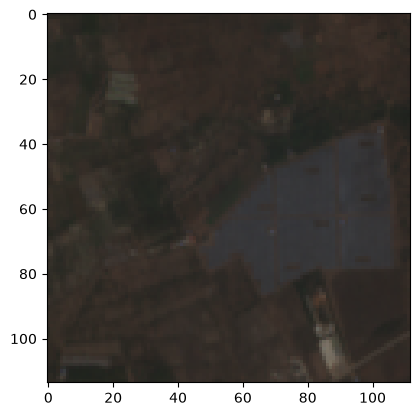

In [81]:
print(ds.time.values)
ds_jan_5 = ds.sel(time='2026-01-05')*0.0001
# The RGB image needs the channels arranged as: (height, width, 3)
rgb_stack = np.stack([ds_jan_5.B04.values[0],
          ds_jan_5.B03.values[0],
          ds_jan_5.B02.values[0]], axis=-1)
plt.imshow(rgb_stack)

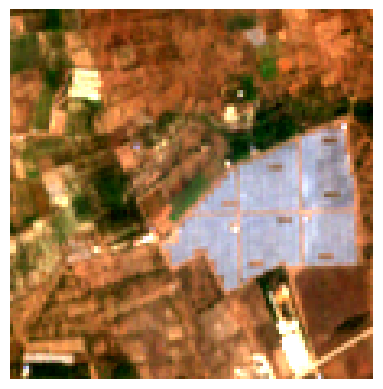

In [75]:
p2 = np.percentile(rgb_stack, 2)
p98 = np.percentile(rgb_stack, 98)
# applied contrast stretching
rgb_stretched = np.clip((rgb_stack-p2)/(p98-p2), 0, 1)
plt.imshow(rgb_stretched)
plt.axis("off")
plt.show()

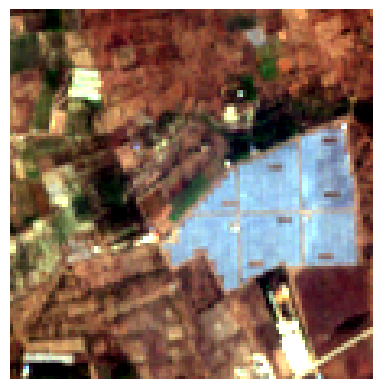

In [78]:
def stretch(band, lower=2, upper=98):

    low = np.nanpercentile(band, lower)
    high = np.nanpercentile(band, upper)

    return np.clip(
        (band - low) / (high - low),
        0,
        1
    )
red = stretch(ds_jan_5.B04.values)[0]
green = stretch(ds_jan_5.B03.values)[0]
blue = stretch(ds_jan_5.B02.values)[0]
nir = stretch(ds_jan_5.B08.values)[0]
rgb_image = np.stack(
    [red, green, blue],
    axis=-1
)
fcc_image = np.stack(
    [nir, red, green],
    axis=-1
)
plt.imshow(rgb_image)
plt.axis("off")
plt.show()

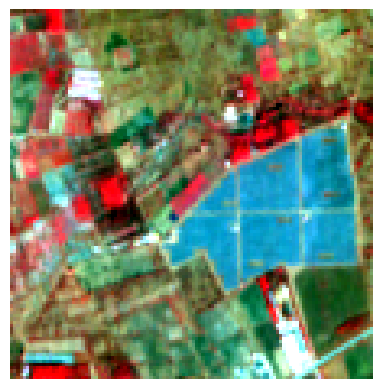

In [79]:
plt.imshow(fcc_image)
plt.axis("off")
plt.show()

## Create a raster mask based on polygon

In [82]:
from rasterio.features import geometry_mask
from shapely.geometry import mapping

In [89]:
dir(ds.odc.geobox)

['__and__',
 '__bool__',
 '__class__',
 '__dask_tokenize__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__mul__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__rmul__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '_affine',
 '_confirm_axis_aligned',
 '_crs',
 '_extent',
 '_lazy_ui',
 '_repr_html_',
 '_repr_svg_',
 '_reproject_resolution',
 '_shape',
 '_ui',
 'affine',
 'alignment',
 'anchor',
 'aspect',
 'axis_aligned',
 'bottom',
 'boundary',
 'boundingbox',
 'buffered',
 'center_pixel',
 'compat',
 'compute_crop',
 'compute_zoom_out',
 'compute_zoom_to',
 'coordinates',
 'coords',
 'crop',
 'crs',
 'dimensions',
 'dims',
 'enclosing',
 'expand',
 'explore',
 'extent',
 'flipx',
 'flipy',
 'footprint',
 'from_bbox',
 'from_geopoly

In [134]:
gdf_utm = gdf.to_crs(utm_crs)
farm_mapping = mapping(gdf_utm.geometry.iloc[0])
transform = ds.odc.geobox.transform
height = ds.sizes['y']
weight = ds.sizes['x']
farm_mask  = geometry_mask([farm_mapping], out_shape=(height, weight), transform=transform, invert=True)


In [97]:
import xarray as xr

In [193]:
farm_mask_xr = xr.DataArray(farm_mask, dims=("y", "x"), coords={"y":ds.y, "x":ds.x})
ds_cliped = ds.ndvi.where(farm_mask_xr)

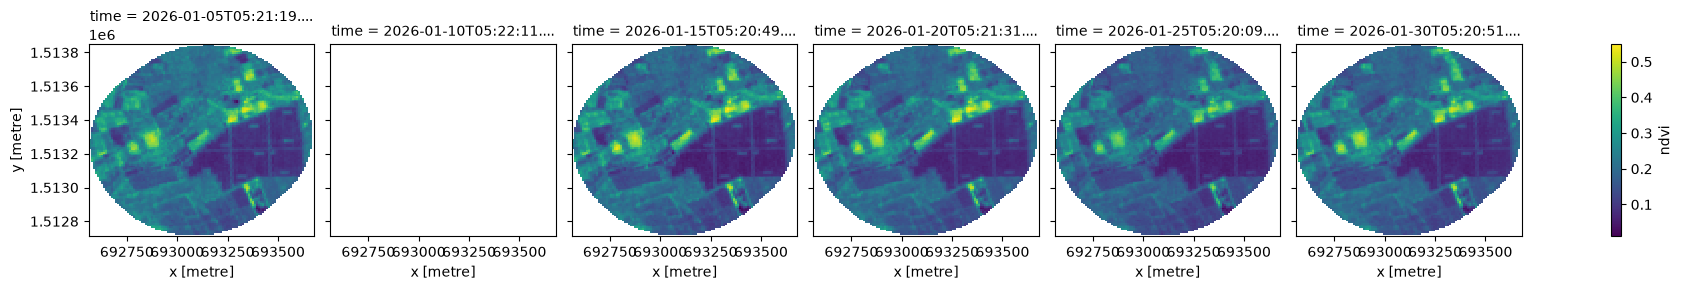

In [194]:
ds_cliped.plot(col='time')

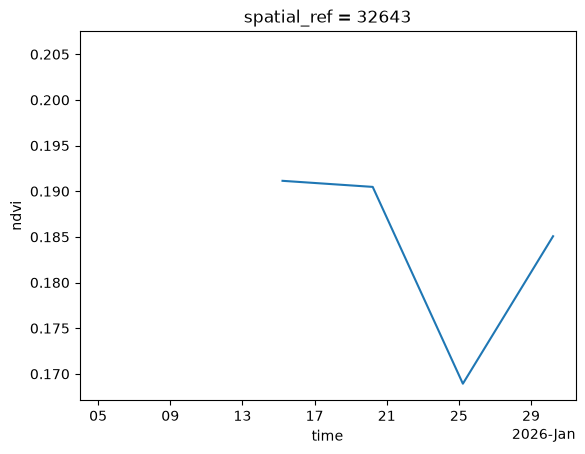

In [146]:
ds_cliped.mean(dim=["x", "y"]).plot()
# ds_cliped.mean(dim=["time"]).plot()

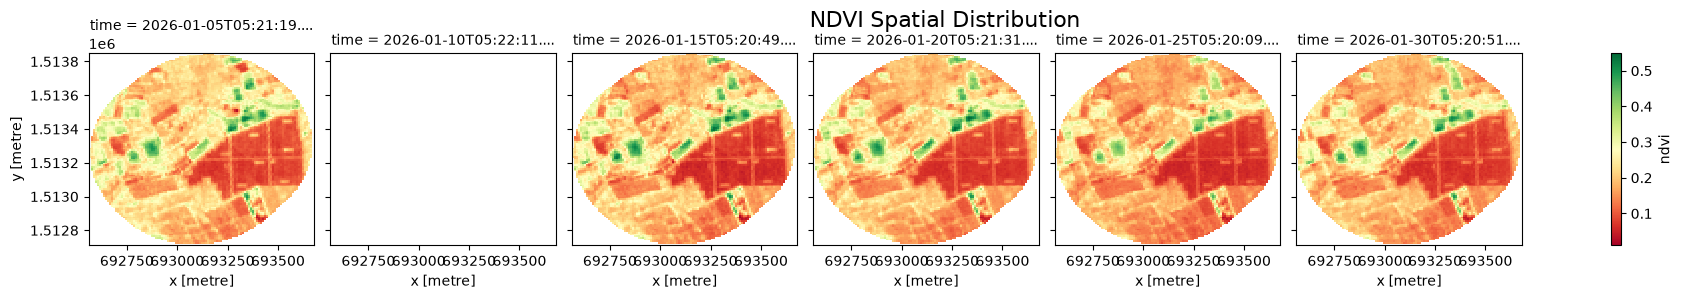

In [ ]:
p = ds_cliped.plot(
    col="time",
    cmap="RdYlGn",
    # figsize=(12, 8)
)

p.fig.suptitle(
    "NDVI Spatial Distribution",
    fontsize=16
)

# p.fig.savefig(
#     "NDVI_spatial_time_series.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

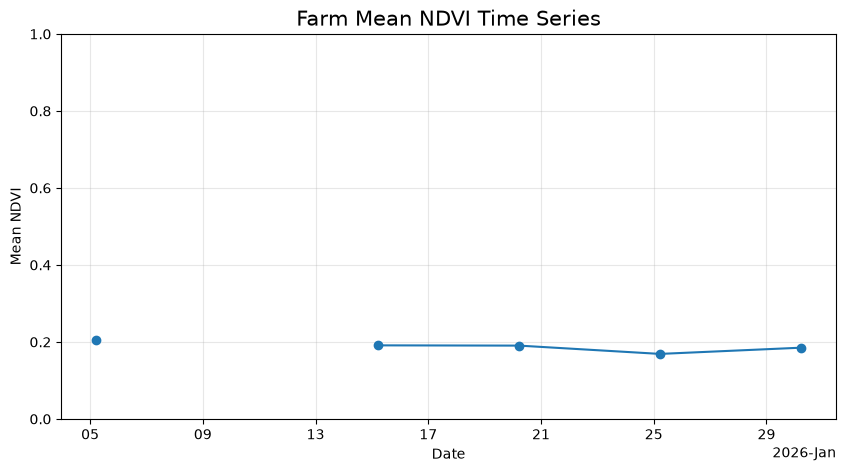

In [152]:
farm_ndvi = ds_cliped.mean(dim=["x", "y"])

fig, ax = plt.subplots(figsize=(10, 5))

farm_ndvi.plot(
    ax=ax,
    marker="o"
)

ax.set_title(
    "Farm Mean NDVI Time Series",
    fontsize=15
)

ax.set_xlabel("Date")
ax.set_ylabel("Mean NDVI")

ax.grid(True, alpha=0.3)
ax.set_ylim((0,1))

# fig.savefig(
#     "farm_mean_ndvi_timeseries.png",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

# reproject the raster

In [154]:
import rioxarray

In [160]:
ds.odc.geobox.crs

CRS('PROJCRS["WGS 84 / UTM zone 43N",BASEGEOGCRS["WGS 84",ENSEMBLE["World Geodetic System 1984 ensemble",MEMBER["World Geodetic System 1984 (Transit)"],MEMBER["World Geodetic System 1984 (G730)"],MEMBER["World Geodetic System 1984 (G873)"],MEMBER["World Geodetic System 1984 (G1150)"],MEMBER["World Geodetic System 1984 (G1674)"],MEMBER["World Geodetic System 1984 (G1762)"],MEMBER["World Geodetic System 1984 (G2139)"],MEMBER["World Geodetic System 1984 (G2296)"],ELLIPSOID["WGS 84",6378137,298.257223563,LENGTHUNIT["metre",1]],ENSEMBLEACCURACY[2.0]],PRIMEM["Greenwich",0,ANGLEUNIT["degree",0.0174532925199433]],ID["EPSG",4326]],CONVERSION["UTM zone 43N",METHOD["Transverse Mercator",ID["EPSG",9807]],PARAMETER["Latitude of natural origin",0,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8801]],PARAMETER["Longitude of natural origin",75,ANGLEUNIT["degree",0.0174532925199433],ID["EPSG",8802]],PARAMETER["Scale factor at natural origin",0.9996,SCALEUNIT["unity",1],ID["EPSG",8805]],PARAMETER["Fal

In [166]:
ndvi = ndvi.rio.write_crs(ds.odc.geobox.crs)
ndvi_4326 = ndvi.rio.reproject("EPSG:4326")
ndvi_4326

<xarray.DataArray (time: 6, y: 114, x: 114)> Size: 312kB
array([[[       nan, 0.2582038 , 0.26721275, ...,        nan,
                nan,        nan],
        [       nan, 0.30406505, 0.2918543 , ..., 0.21197793,
         0.19750682, 0.17218544],
        [       nan, 0.22896855, 0.20728597, ..., 0.21409002,
         0.20670392, 0.16816817],
        ...,
        [0.2545099 , 0.25992543, 0.3187473 , ..., 0.13542977,
         0.1574904 ,        nan],
        [0.23334765, 0.26686218, 0.3036566 , ..., 0.16514954,
         0.19317926,        nan],
        [       nan,        nan,        nan, ..., 0.16854969,
         0.18066636,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [0.21097615, 0.21968062, 0.2807175 , ..., 0.12341505,
         0.14347172,        nan],
        [0.21493703, 0.23050848, 0.25282362, ..., 0.16038562,
         0.18256131,        nan],
        [       nan,        nan,        nan, ..., 0.1482001 ,
         0.17496444,        nan]],

       [[       nan, 0.22663252, 0.22994652, ...,        nan,
                nan,        nan],
        [       nan, 0.26302627, 0.24346744, ..., 0.18946145,
         0.16394717, 0.14877868],
        [       nan, 0.18090264, 0.16199848, ..., 0.17985612,
         0.18697897, 0.15333822],
        ...,
        [0.24218051, 0.24967434, 0.2889185 , ..., 0.13429157,
         0.16300675,        nan],
        [0.24690016, 0.2663066 , 0.2892697 , ..., 0.17626826,
         0.22139412,        nan],
        [       nan,        nan,        nan, ..., 0.18081181,
         0.1961326 ,        nan]]], shape=(6, 114, 114), dtype=float32)
Coordinates:
  * time         (time) datetime64[us] 48B 2026-01-05T05:21:19.024000 ... 202...
  * y            (y) float64 912B 13.69 13.69 13.69 13.69 ... 13.68 13.68 13.68
  * x            (x) float64 912B 76.78 76.78 76.78 76.78 ... 76.79 76.79 76.79
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:  nan

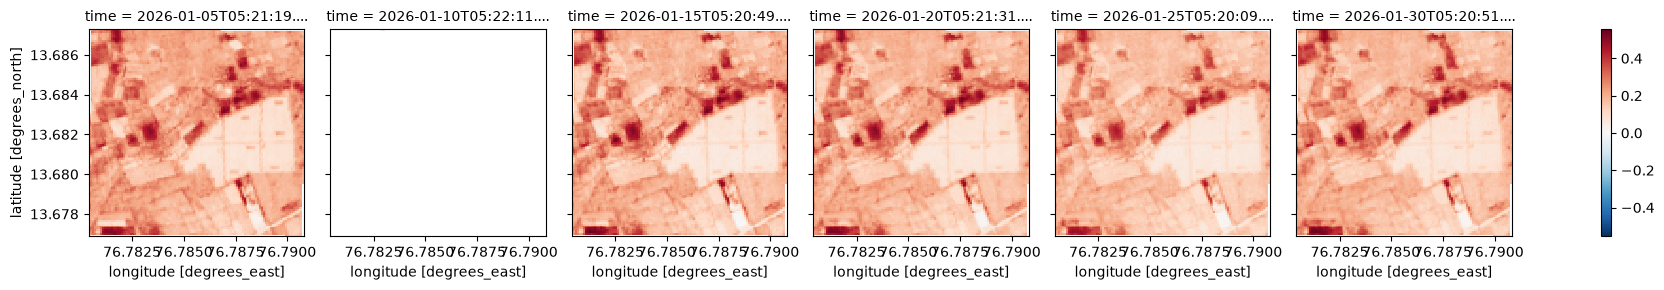

In [168]:
ndvi_4326.plot(col="time")

C:\Users\HP\AppData\Local\Temp\ipykernel_3564\698384531.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(
C:\Users\HP\AppData\Local\Temp\ipykernel_3564\698384531.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels(


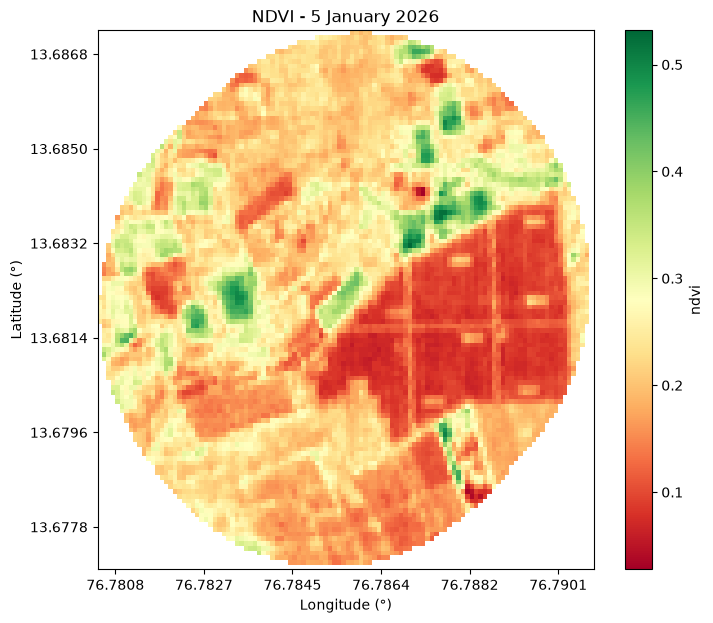

In [169]:
import matplotlib.pyplot as plt
from pyproj import Transformer

fig, ax = plt.subplots(figsize=(8, 7))

ds_cliped.isel(time=0).plot(
    ax=ax,
    cmap="RdYlGn"
)

ax.set_title("NDVI - 5 January 2026")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")

transformer = Transformer.from_crs(
    ds_cliped.odc.geobox.crs,
    "EPSG:4326",
    always_xy=True
)

# Existing UTM tick positions
x_ticks = ax.get_xticks()
y_ticks = ax.get_yticks()

# Transform UTM → lon/lat
lon_ticks, _ = transformer.transform(
    x_ticks,
    [ds_cliped.y.mean().item()] * len(x_ticks)
)

_, lat_ticks = transformer.transform(
    [ds_cliped.x.mean().item()] * len(y_ticks),
    y_ticks
)

ax.set_xticklabels(
    [f"{lon:.4f}" for lon in lon_ticks]
)

ax.set_yticklabels(
    [f"{lat:.4f}" for lat in lat_ticks]
)

fig.savefig(
    "NDVI_lon_lat.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## download with original resolution

In [ ]:
import matplotlib.pyplot as plt
from pyproj import Transformer

fig, ax = plt.subplots(figsize=(8, 7))

ds_cliped.isel(time=0).plot(
    ax=ax,
    cmap="RdYlGn"
)

ax.set_title("NDVI - 5 January 2026")
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")

transformer = Transformer.from_crs(
    ds_cliped.odc.geobox.crs,
    "EPSG:4326",
    always_xy=True
)

# Existing UTM tick positions
x_ticks = ax.get_xticks()
y_ticks = ax.get_yticks()

# Transform UTM → lon/lat
lon_ticks, _ = transformer.transform(
    x_ticks,
    [ds_cliped.y.mean().item()] * len(x_ticks)
)

_, lat_ticks = transformer.transform(
    [ds_cliped.x.mean().item()] * len(y_ticks),
    y_ticks
)

ax.set_xticklabels(
    [f"{lon:.4f}" for lon in lon_ticks]
)

ax.set_yticklabels(
    [f"{lat:.4f}" for lat in lat_ticks]
)

fig.savefig(
    "NDVI_lon_lat.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [180]:
ndvi

<xarray.DataArray (time: 6, y: 114, x: 112)> Size: 306kB
array([[[0.2582038 , 0.26721275, 0.26167402, ..., 0.21197793,
         0.19750682, 0.17218544],
        [0.30406505, 0.2918543 , 0.26600167, ..., 0.21409002,
         0.20670392, 0.16816817],
        [0.22896855, 0.20728597, 0.17487141, ..., 0.22220035,
         0.24733876, 0.20414507],
        ...,
        [0.3099662 , 0.27592632, 0.30858678, ..., 0.12816326,
         0.13542977, 0.1574904 ],
        [0.2545099 , 0.25992543, 0.3187473 , ..., 0.14884607,
         0.16514954, 0.19317926],
        [0.23334765, 0.26686218, 0.3036566 , ..., 0.15005624,
         0.16854969, 0.18066636]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [0.25021872, 0.23227176, 0.25381288, ..., 0.10825384,
         0.12341505, 0.14347172],
        [0.21097615, 0.21968062, 0.2807175 , ..., 0.12510711,
         0.16038562, 0.18256131],
        [0.21493703, 0.23050848, 0.25282362, ..., 0.12700596,
         0.1482001 , 0.17496444]],

       [[0.22663252, 0.22994652, 0.2059279 , ..., 0.18946145,
         0.16394717, 0.14877868],
        [0.26302627, 0.24346744, 0.2058142 , ..., 0.17985612,
         0.18697897, 0.15333822],
        [0.18090264, 0.16199848, 0.15293215, ..., 0.1867065 ,
         0.1995173 , 0.17898063],
        ...,
        [0.29209015, 0.26262838, 0.27607915, ..., 0.12205045,
         0.13429157, 0.16300675],
        [0.24218051, 0.24967434, 0.2889185 , ..., 0.13682432,
         0.17626826, 0.22139412],
        [0.24690016, 0.2663066 , 0.2892697 , ..., 0.14545454,
         0.18081181, 0.1961326 ]]], shape=(6, 114, 112), dtype=float32)
Coordinates:
  * time         (time) datetime64[us] 48B 2026-01-05T05:21:19.024000 ... 202...
  * y            (y) float64 912B 1.514e+06 1.514e+06 ... 1.513e+06 1.513e+06
  * x            (x) float64 896B 6.926e+05 6.926e+05 ... 6.937e+05 6.937e+05
    spatial_ref  int64 8B 0

# 1. Save a single-band raster as GeoTIFF

In [183]:
geobox = ds_cliped.odc.geobox

profile = {
    "driver": "GTiff",
    "height": ndvi.sizes["y"],
    "width": ndvi.sizes["x"],
    "count": 1,
    "dtype": str(ndvi.dtype),
    "crs": geobox.crs,
    "transform": geobox.transform,
    "compress": "deflate"
}

with rasterio.open(
    r"..\output\indices\NDVI_2026_01_05.tif",
    "w",
    **profile
) as dst:

    dst.write(
        ndvi.values[0],
        1
    )

    # Band name
    dst.set_band_description(
        1,
        "NDVI"
    )

    # File-level metadata
    dst.update_tags(
        product="Sentinel-2 L2A",
        variable="NDVI",
        processing="ODC-STAC",
        processing_level="derived",
        date=str(ndvi.time.values) if "time" in ndvi.coords else "unknown"
    )

In [184]:
import rasterio


def save_dataarray_geotiff(
    da,
    output_path,
    variable_name,
    geobox,
    **metadata
):

    profile = {
        "driver": "GTiff",
        "height": da.sizes["y"],
        "width": da.sizes["x"],
        "count": 1,
        "dtype": str(da.dtype),
        "crs": geobox.crs,
        "transform": geobox.transform,
        "compress": "deflate"
    }

    with rasterio.open(
        output_path,
        "w",
        **profile
    ) as dst:

        dst.write(
            da.values,
            1
        )

        # Band metadata
        dst.set_band_description(
            1,
            variable_name
        )

        # Add xarray variable attributes
        tags = {}

        for key, value in da.attrs.items():
            tags[str(key)] = str(value)

        # Add our metadata
        tags.update(
            {key: str(value) for key, value in metadata.items()}
        )

        dst.update_tags(**tags)

# save_dataarray_geotiff(
#     ds_cliped.NDVI.isel(time=0),
#     "NDVI_2026-01-05.tif",
#     "NDVI",
#     ds_cliped.odc.geobox,
#     product="Sentinel-2 L2A",
#     processing="ODC-STAC",
#     date="2026-01-05"
# )

# 5. Export every date as a separate GeoTIFF

In [188]:
ds_cliped

<xarray.DataArray 'ndvi' (time: 6, y: 114, x: 112)> Size: 306kB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(6, 114, 112), dtype=float32)
Coordinates:
  * time         (time) datetime64[us] 48B 2026-01-05T05:21:19.024000 ... 202...
  * y            (y) float64 912B 1.514e+06 1.514e+06 ... 1.513e+06 1.513e+06
  * x            (x) float64 896B 6.926e+05 6.926e+05 ... 6.937e+05 6.937e+05
    spatial_ref  int32 4B 32643

In [199]:
ds_cliped['ndvi']= ds_cliped

In [200]:
for i in range(ds_cliped.sizes["time"]):

    da = ds_cliped.ndvi.isel(time=i)

    date = da.time.dt.strftime("%Y-%m-%d").item()

    filename = fr"..\output\indices\NDVI_{date}.tif"

    save_dataarray_geotiff(
        da,
        filename,
        "NDVI",
        ds_cliped.odc.geobox,
        product="Sentinel-2 L2A",
        processing="ODC-STAC",
        date=date
    )

# 2  Export multiple bands into ONE GeoTIFF

In [203]:
bands = ["B04", "B08", "ndvi"]
ds_one_date = ds.isel(time=0)

bands = ["B04", "B08", "ndvi"]
for band in bands:
    print(
        band,
        ds_one_date[band].shape,
        ds_one_date[band].dims
    )

B04 (114, 112) ('y', 'x')
B08 (114, 112) ('y', 'x')
ndvi (114, 112) ('y', 'x')


In [208]:
import numpy as np
import rasterio

geobox = ds_cliped.odc.geobox

with rasterio.open(
    r"..\output\indices\Sentinel2_2026-01-05.tif",
    "w",
    # driver="GTiff",
    driver="COG", # to save with COG
    height=ds_one_date.sizes["y"],
    width=ds_one_date.sizes["x"],
    count=len(bands),
    dtype="float32",
    crs=geobox.crs,
    transform=geobox.transform,
    compress="deflate",
    block_size=256
) as dst:

    for band_number, band_name in enumerate(bands, start=1):

        data = ds_one_date[band_name].values.astype(
            np.float32
        )

        dst.write(
            data,
            band_number
        )

        # Store actual band/variable name
        dst.set_band_description(
            band_number,
            band_name
        )

        # Store band-specific metadata
        dst.update_tags(
            band_number,
            variable=band_name,
            source="Sentinel-2 L2A",
            processing="ODC-STAC"
        )

    # File-level metadata
    dst.update_tags(
        product="Sentinel-2 L2A",
        date=str(ds_one_date.time.values),
        processing="ODC-STAC",
        description="Sentinel-2 bands and derived NDVI"
    )

# 2. Save as Cloud Optimized GeoTIFF (COG)

In [171]:
import odc.stac
import odc.geo

print("odc.stac:", odc.stac.__version__)
print("odc.geo:", odc.geo.__version__)

odc.stac: 0.5.3
odc.geo: 0.5.3


# 3 Save as netcdf

In [173]:
ds_cliped.to_netcdf(
    r"..\output\raw_satellite_data\sentinel2_analysis.nc"
)